# Лабораторная работа №5

Моделирование сети массового обслуживания с динамическими агентами на примере `RPC`-сервиса для `key-value` хранилища.


## Предметная область

Сеть состоит из трех узлов:

- `RPC Gateway` --- прием и разбор RPC-запроса;
- `Application Logic` --- прикладная логика;
- `Storage + Response` --- работа с хранилищем и отправка ответа.

Каждая заявка проходит все три узла. В каждом узле число активных агентов меняется во времени, поэтому фактическая пропускная способность сети является динамической.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from generate_lab5_artifacts import (
    DATABASE_SIZE,
    LAMBDA_QPS,
    MU_RESP_QPS,
    MU_RPC_QPS,
    REPLICATIONS,
    SIMULATION_TIME_SEC,
    estimate_service_model,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


## Параметры модели


In [2]:
pd.DataFrame([
    {"Параметр": "λ", "Значение": f"{LAMBDA_QPS} qps"},
    {"Параметр": "μ_rpc", "Значение": f"{MU_RPC_QPS} qps"},
    {"Параметр": "μ_resp", "Значение": f"{MU_RESP_QPS} qps"},
    {"Параметр": "Размер БД", "Значение": DATABASE_SIZE},
    {"Параметр": "Время моделирования", "Значение": f"{SIMULATION_TIME_SEC} с"},
    {"Параметр": "Число прогонов", "Значение": REPLICATIONS},
])


,Параметр,Значение
0,λ,3.2 qps
1,μ_rpc,30.0 qps
2,μ_resp,40.0 qps
3,Размер БД,1000
4,Время моделирования,3000.0 с
5,Число прогонов,12


## Оценка сервисной модели


In [3]:
service_model = estimate_service_model(MU_RPC_QPS, MU_RESP_QPS, DATABASE_SIZE)
node_service_summary = pd.DataFrame([
    {"Узел": node_name, "E[S_i], мс": service_model["node_service_time_ms"][node_name], "mu_i, qps": service_model["node_mu_qps"][node_name]}
    for node_name in service_model["node_service_time_ms"]
])
display(node_service_summary.round(3))
pd.Series({
    "E[S_total], с": service_model["mean_total_service_time_sec"],
    "E[S_total], мс": service_model["mean_total_service_time_ms"],
    "mu_eff_total, qps": service_model["mu_eff_total_qps"],
}).round(4)


,Узел,"E[S_i], мс","mu_i, qps"
0,RPC Gateway,48.274,20.715
1,Application Logic,89.510,11.172
2,Storage + Response,69.689,14.349


E[S_total], с          0.2075
E[S_total], мс       207.4730
mu_eff_total, qps      4.8199
dtype: float64

## Математическая постановка

Для каждого узла вводятся:

- `μ_i` --- интенсивность обслуживания одного агента;
- `m_i(t)` --- текущее число активных агентов;
- `α_i` --- интенсивность подключений;
- `β_i` --- интенсивность отключений.

Текущая пропускная способность узла:

$$
\mu_i^{total}(t) = m_i(t) \mu_i
$$

Если средний входящий поток на узел длительно превышает его среднюю пропускную способность, в узле начинает расти очередь и он становится узким местом сети.


In [4]:
summary = json.loads(Path("lab5_summary.json").read_text(encoding="utf-8"))


## Базовый эксперимент


In [5]:
base_network = pd.DataFrame([summary["base_results"]["network"]]).drop(columns=["node_waits_ms", "node_queue_lengths", "node_active_agents", "node_utilization"])
base_nodes = pd.DataFrame(summary["base_results"]["nodes"])
print("Метрики сети:")
display(base_network.round(3))
print("Метрики узлов:")
display(base_nodes.round(3))


Метрики сети:


,mean_network_time_ms,mean_network_time_ms_std,mean_network_queue,mean_network_queue_std,mean_network_system,mean_network_system_std,mean_active_agents_total,mean_active_agents_total_std,completed_requests,completed_requests_std,loss_probability,loss_probability_std
0,217.201,1.207,0.031,0.002,0.693,0.007,8.787,0.066,9568.333,92.94,0.0,0.0


Метрики узлов:


,node_name,mean_wait_ms,mean_service_ms,mean_queue_length,mean_active_agents_node,utilization_node,arrivals,completions,connect_events,disconnect_events
0,RPC Gateway,0.359,48.262,0.001,3.341,0.046,9568.750,9568.750,530.583,529.083
1,Application Logic,7.837,89.605,0.025,2.259,0.127,9568.750,9568.417,569.000,569.083
2,Storage + Response,1.476,69.665,0.005,3.187,0.070,9568.417,9568.333,445.750,444.833


## Эксперименты


In [6]:
alpha_experiments = pd.DataFrame(summary["alpha_experiments"])
beta_experiments = pd.DataFrame(summary["beta_experiments"])
lambda_experiments = pd.DataFrame(summary["lambda_experiments"])
agent_limit_experiments = pd.DataFrame(summary["agent_limit_experiments"])

print("Влияние интенсивности подключений:")
display(alpha_experiments.round(3))
print("Влияние интенсивности отключений:")
display(beta_experiments.round(3))
print("Влияние входной интенсивности:")
display(lambda_experiments.round(3))
print("Влияние верхнего предела числа агентов:")
display(agent_limit_experiments.round(3))


Влияние интенсивности подключений:


,alpha_scale,mean_network_time_ms,mean_network_queue,mean_active_agents_total,app_logic_wait_ms
0,0.50,231.695,0.078,6.831,17.725
1,0.75,222.272,0.049,8.072,12.094
2,1.00,217.101,0.032,8.792,8.221
3,1.25,215.075,0.024,9.260,6.349
4,1.50,213.204,0.018,9.578,4.893


Влияние интенсивности отключений:


,beta_scale,mean_network_time_ms,mean_network_queue,mean_active_agents_total,app_logic_queue
0,0.50,210.551,0.011,9.986,0.010
1,0.75,213.990,0.023,9.338,0.019
2,1.00,217.170,0.034,8.780,0.028
3,1.25,220.862,0.041,8.214,0.032
4,1.50,224.043,0.052,7.746,0.039


Влияние входной интенсивности:


,lambda_qps,mean_network_time_ms,mean_network_queue,mean_active_agents_total,app_logic_wait_ms
0,2.0,212.717,0.011,8.783,4.418
1,2.8,215.432,0.022,8.827,6.477
2,3.6,219.027,0.043,8.803,9.887
3,4.4,222.597,0.070,8.780,13.067
4,5.2,229.221,0.110,8.781,17.602


Влияние верхнего предела числа агентов:


,max_agents,mean_network_time_ms,mean_network_queue,mean_active_agents_total,app_logic_utilization
0,2,231.311,0.076,4.943,0.178
1,3,218.605,0.036,7.122,0.126
2,4,213.320,0.019,9.537,0.095
3,5,210.959,0.012,12.100,0.076


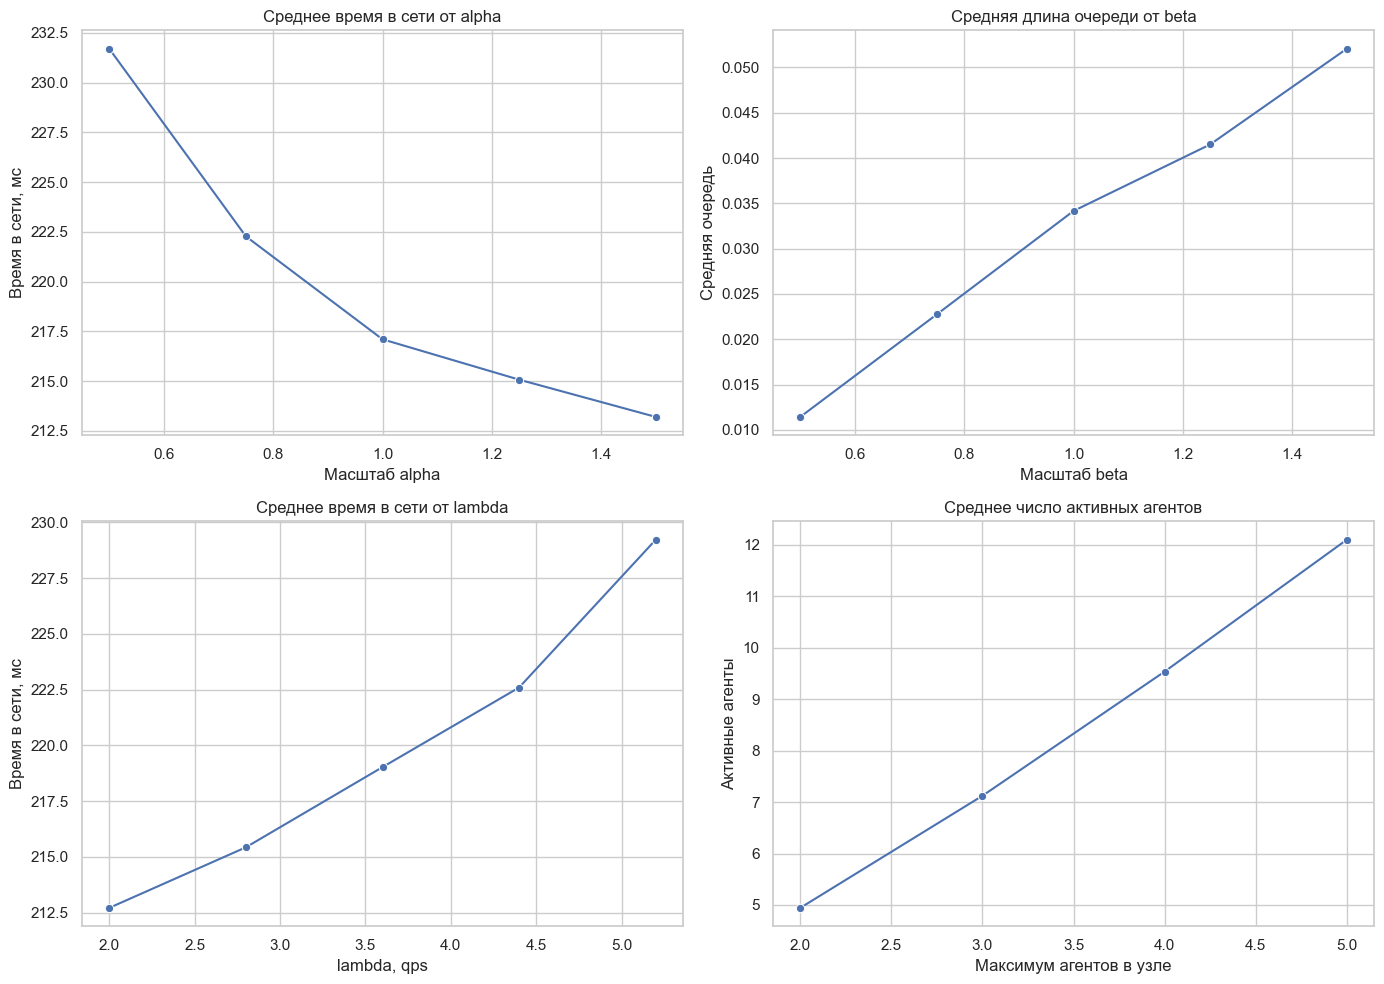

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.lineplot(data=alpha_experiments, x="alpha_scale", y="mean_network_time_ms", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Среднее время в сети от alpha")
axes[0, 0].set_xlabel("Масштаб alpha")
axes[0, 0].set_ylabel("Время в сети, мс")

sns.lineplot(data=beta_experiments, x="beta_scale", y="mean_network_queue", marker="o", ax=axes[0, 1])
axes[0, 1].set_title("Средняя длина очереди от beta")
axes[0, 1].set_xlabel("Масштаб beta")
axes[0, 1].set_ylabel("Средняя очередь")

sns.lineplot(data=lambda_experiments, x="lambda_qps", y="mean_network_time_ms", marker="o", ax=axes[1, 0])
axes[1, 0].set_title("Среднее время в сети от lambda")
axes[1, 0].set_xlabel("lambda, qps")
axes[1, 0].set_ylabel("Время в сети, мс")

sns.lineplot(data=agent_limit_experiments, x="max_agents", y="mean_active_agents_total", marker="o", ax=axes[1, 1])
axes[1, 1].set_title("Среднее число активных агентов")
axes[1, 1].set_xlabel("Максимум агентов в узле")
axes[1, 1].set_ylabel("Активные агенты")

plt.tight_layout()
plt.show()


## Временные графики


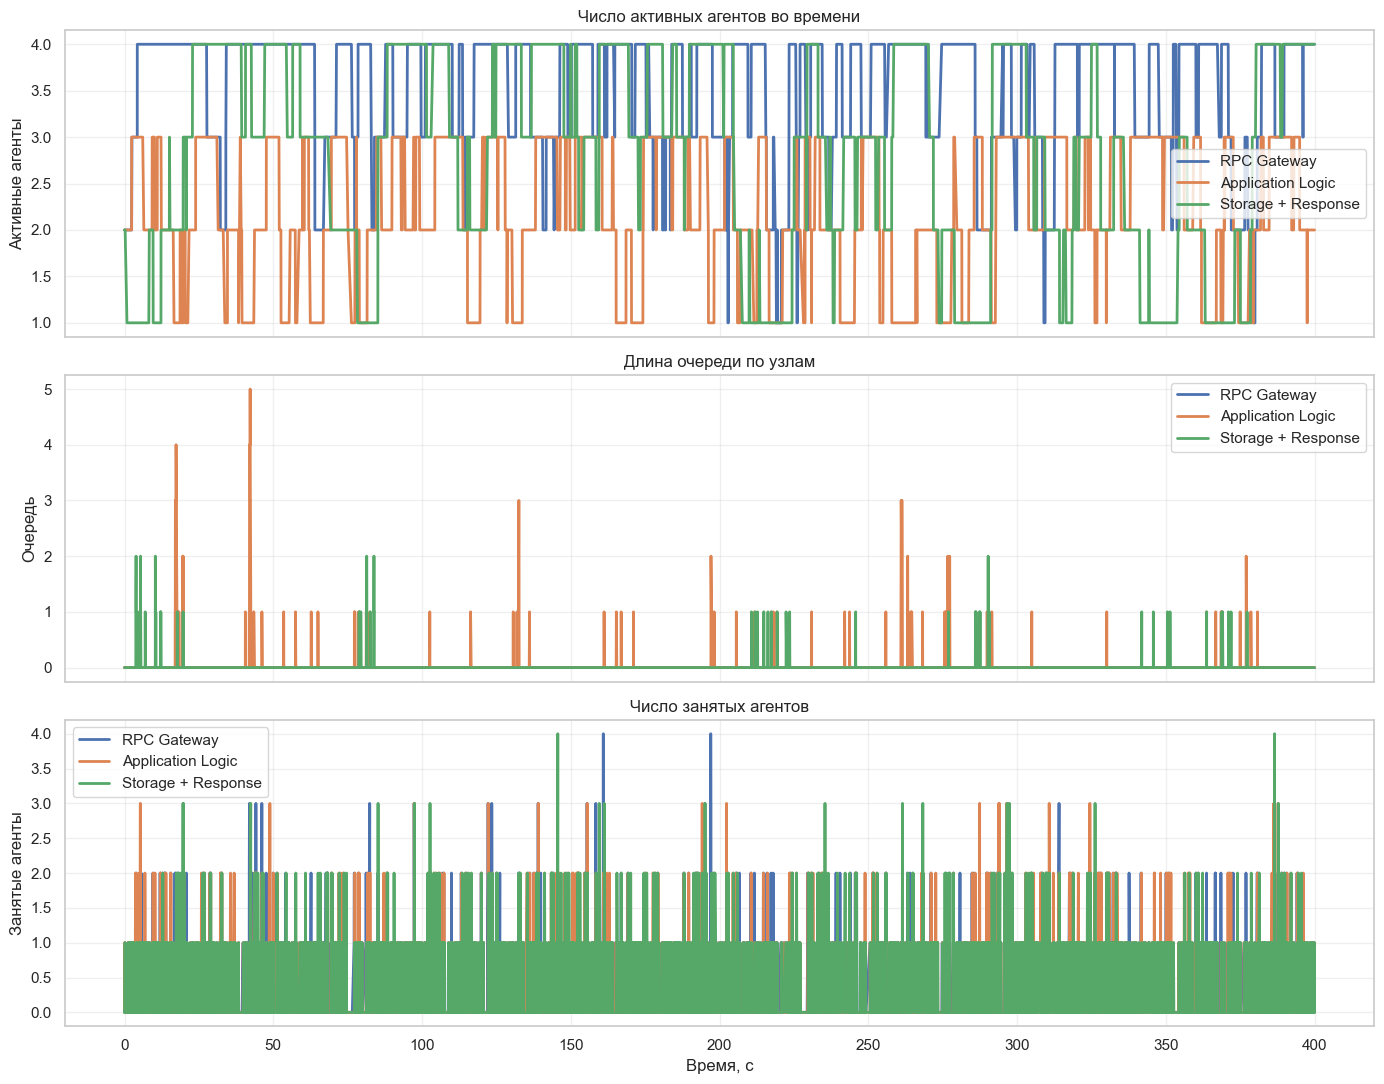

In [8]:
timeline = summary["timeline_results"]
time_grid = timeline["time"]
node_names = list(timeline["nodes"].keys())

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
for node_name in node_names:
    axes[0].plot(time_grid, timeline["nodes"][node_name]["active_agents"], label=node_name, linewidth=2)
    axes[1].plot(time_grid, timeline["nodes"][node_name]["queue"], label=node_name, linewidth=2)
    axes[2].plot(time_grid, timeline["nodes"][node_name]["busy_agents"], label=node_name, linewidth=2)

axes[0].set_title("Число активных агентов во времени")
axes[0].set_ylabel("Активные агенты")
axes[1].set_title("Длина очереди по узлам")
axes[1].set_ylabel("Очередь")
axes[2].set_title("Число занятых агентов")
axes[2].set_ylabel("Занятые агенты")
axes[2].set_xlabel("Время, с")
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


## Сценарный анализ


In [9]:
scenario_results = pd.DataFrame(summary["scenario_results"])
display(scenario_results.round(3))


,scenario,lambda_qps,alpha_scale,beta_scale,mean_network_time_ms,mean_network_queue,mean_active_agents_total,app_logic_wait_ms
0,Стабильная сеть,2.6,1.20,0.70,209.824,0.009,9.764,2.876
1,Базовый режим,3.2,1.00,1.00,216.901,0.031,8.822,8.108
2,Высокая нестабильность агентов,3.2,0.85,1.35,225.432,0.059,7.539,13.594
3,Высокая нагрузка,4.8,1.00,1.00,225.923,0.092,8.766,15.925
4,Улучшенный режим,4.8,1.25,0.85,190.320,0.009,13.227,1.610


## Выводы

1. Динамика агентов напрямую влияет на текущую пропускную способность узлов.
2. В базовом режиме узел `Application Logic` чаще всего становится узким местом.
3. Рост интенсивности отключений увеличивает очереди и среднее время пребывания заявки в сети.
4. Рост интенсивности подключений и увеличение лимита числа агентов стабилизируют сеть.
